### Building a basic chatbot with langgraph(GRAPH API)


components of langgraph
- edges
- nodes
- states

//Let's say we want to create Blog from YT video
---[ transcript]---[title generator]---[content generator]--(nodes+edges)(LLM +Prompt for title and content generation) {states can be accessed by any nodes and contains info in lets say variables}{its not memory}[state graph]


In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


// add_mesages to append message (reducers) in single variable

In [15]:
class State(TypedDict):
    #Messages have the type list. The 'add_messages' function
    #in the annotation defines how this state key should be updated 
    #(in this case, it appends messages to the list , rathr than overwriting them)
    messages: Annotated[list, add_messages] #reducer
    


In [10]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [11]:
from langchain_groq import ChatGroq

In [12]:
from langchain.chat_models import init_chat_model

In [25]:
llm=ChatGroq(model="qwen/qwen3-32b")

In [26]:
## node functionality
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

In [27]:
graph_builder=StateGraph(State)
graph_builder.add_node("chatbot", chatbot)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph=graph_builder.compile()

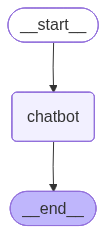

In [28]:
graph

In [29]:
graph.invoke({"messages":[{"role":"user","content":"What is the capital of France?"}]})

{'messages': [HumanMessage(content='What is the capital of France?', additional_kwargs={}, response_metadata={}, id='f5c59130-b573-431d-b583-b542e0bdfc6a'),
  AIMessage(content="<think>\nOkay, the user is asking for the capital of France. Let me think. I remember from school that France's capital is Paris. But wait, is that still the case? I should double-check. Maybe there's some recent change or maybe they're a bit confused. Let me recall: France is a country in Western Europe, and Paris is a major city there. Yeah, Paris is definitely the capital. I think the government is based there, and it's the largest city. No, I don't think there's any other city that's been the capital recently. Maybe they're tricking me, but I'm pretty confident it's Paris. I should just confirm once more. Quick search in my mind... Yep, Paris has been the capital since the 12th century, except for a brief period during World War II when the government moved to Vichy, but that's not the official capital. So 

In [30]:
for event in graph.stream({"messages":[{"role":"user","content":"What is the capital of France?"}]}):
    print(event)

{'chatbot': {'messages': [AIMessage(content="<think>\nOkay, the user is asking for the capital of France. Let me think. I remember that France is a country in Europe. The capital is a major city. I think it's either Paris or Lyon. Wait, Paris is the capital, right? Lyon is another big city but not the capital. Let me verify. I've heard a lot about Paris being the capital, known for the Eiffel Tower and the Louvre. Yeah, that's right. So the capital of France is Paris. I should also mention the population maybe, like around 2.1 million people in the city. Also, it's a global city and a cultural hub. Should I add any other details? Maybe the region it's in, like Île-de-France. But the user might just want the name. Keep it concise but accurate.\n</think>\n\nThe capital of France is **Paris**. It is the largest city in France and a major global hub for art, fashion, and culture, renowned for landmarks like the Eiffel Tower, the Louvre Museum, and Notre-Dame Cathedral. Paris is located in 